# 06. CLUSTERING ANALYSIS - PHÂN NHÓM DỮ LIỆU

## Mục Tiêu
Sử dụng **K-Means Clustering** để phân nhóm bài hát dựa trên đặc tính âm học (audio features).

**Objective:**
1. Tìm số cluster tối ưu (Elbow Method + Silhouette Score)
2. Áp dụng K-Means clustering
3. Phân tích đặc tính của mỗi cluster
4. Visualize kết quả clustering
5. Rút ra insights về các nhóm bài hát

In [1]:
# ===== IMPORT LIBRARIES =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
sns.set_style("whitegrid")
print("✅ Thư viện đã sẵn sàng")

✅ Thư viện đã sẵn sàng


In [2]:
# ===== LOAD DATA =====
print("="*100)
print("📊 TẢI DỮ LIỆU CLEANED VÀ SCALED")
print("="*100)

# Tải dữ liệu đã làm sạch và scaled
ml_file = '../data/processed/spotify_for_ml.csv'
df = pd.read_csv(ml_file)

print(f"\n✅ Tải thành công: {ml_file}")
print(f"   Shape: {df.shape}")
print(f"   Columns: {len(df.columns)}")

# Chọn audio features cho clustering
audio_features = ['danceability', 'energy', 'key', 'loudness', 'mode', 
                  'speechiness', 'acousticness', 'instrumentalness', 
                  'liveness', 'valence', 'tempo']

# Lọc dữ liệu có đủ features
df_cluster = df[audio_features].copy()

print(f"\n🎵 Audio Features cho clustering: {len(audio_features)}")
print(f"   {audio_features}")
print(f"\n📈 Dữ liệu clustering: {df_cluster.shape}")
print(f"   Rows: {len(df_cluster):,}")
print(f"   Columns: {len(audio_features)}")

📊 TẢI DỮ LIỆU CLEANED VÀ SCALED

✅ Tải thành công: ../data/processed/spotify_for_ml.csv
   Shape: (12476, 326)
   Columns: 326

🎵 Audio Features cho clustering: 11
   ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

📈 Dữ liệu clustering: (12476, 11)
   Rows: 12,476
   Columns: 11



🔍 TÌM SỐ CLUSTER TỐI ƯU (ELBOW METHOD + SILHOUETTE SCORE)

📊 Tính toán cho K = 2 đến 10...
   K=2: Inertia=108843.35, Silhouette=0.2103
   K=3: Inertia=99718.81, Silhouette=0.1501
   K=4: Inertia=93325.11, Silhouette=0.1379
   K=5: Inertia=87480.17, Silhouette=0.1357
   K=6: Inertia=82555.69, Silhouette=0.1504
   K=7: Inertia=79026.24, Silhouette=0.1450
   K=8: Inertia=75113.69, Silhouette=0.1417
   K=9: Inertia=72274.82, Silhouette=0.1338
   K=10: Inertia=70151.28, Silhouette=0.1397


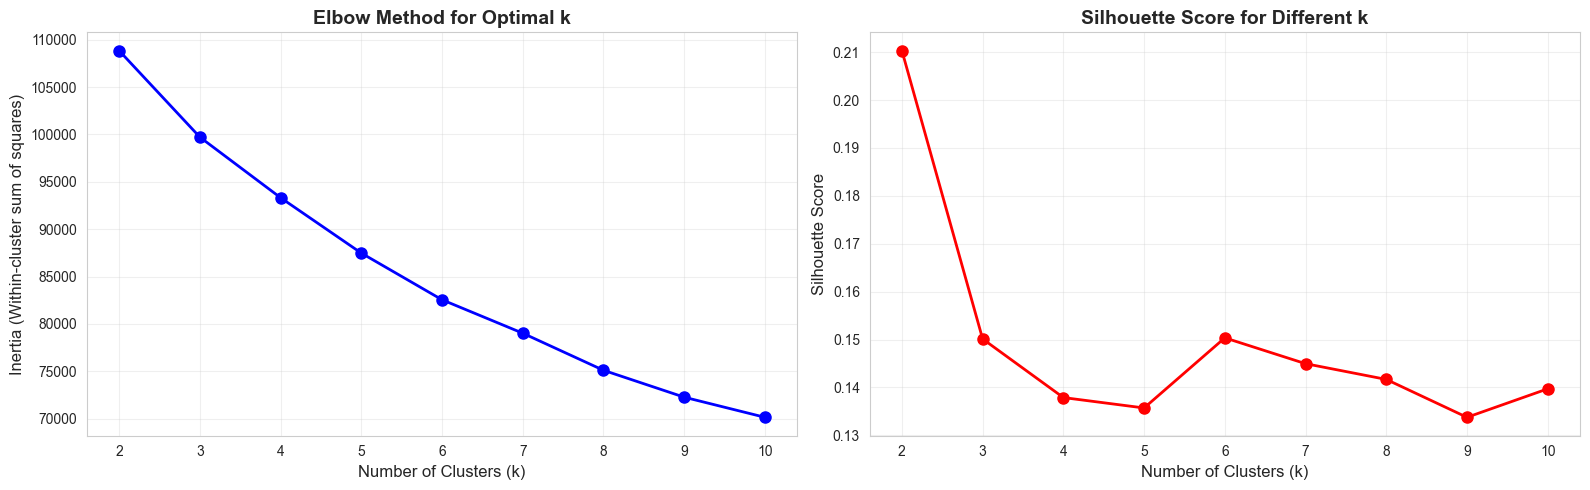


✅ Số cluster tối ưu (theo Silhouette Score): K = 2
   Silhouette Score = 0.2103


In [3]:
# ===== TÌM SỐ CLUSTER TỐI ƯU =====
print("\n" + "="*100)
print("🔍 TÌM SỐ CLUSTER TỐI ƯU (ELBOW METHOD + SILHOUETTE SCORE)")
print("="*100)

# Standardize features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)

# Tính inertia và silhouette score cho từng k
inertias = []
silhouette_scores = []
K_range = range(2, 11)

print("\n📊 Tính toán cho K = 2 đến 10...")
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(df_scaled)
    
    inertias.append(kmeans_temp.inertia_)
    sil_score = silhouette_score(df_scaled, labels_temp)
    silhouette_scores.append(sil_score)
    
    print(f"   K={k}: Inertia={kmeans_temp.inertia_:.2f}, Silhouette={sil_score:.4f}")

# Visualize Elbow Curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Elbow Method
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
ax1.set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Silhouette Score
ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score for Different k', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/elbow_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

# Tìm k tối ưu từ silhouette score
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\n✅ Số cluster tối ưu (theo Silhouette Score): K = {optimal_k}")
print(f"   Silhouette Score = {max(silhouette_scores):.4f}")

In [4]:
# ===== ÁPTỤNG K-MEANS CLUSTERING =====
print("\n" + "="*100)
print(f"🎯 ÁP DỤNG K-MEANS CLUSTERING (K={optimal_k})")
print("="*100)

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

# Thêm cluster labels vào dataframe gốc
df['cluster'] = clusters

print(f"\n✅ K-Means clustering hoàn tất")
print(f"   Tổng samples: {len(df):,}")
print(f"   Số clusters: {optimal_k}")

# Phân bố cluster
print(f"\n📊 Phân bố các cluster:")
cluster_counts = df['cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    percentage = (count / len(df)) * 100
    print(f"   Cluster {cluster_id}: {count:,} tracks ({percentage:.2f}%)")


🎯 ÁP DỤNG K-MEANS CLUSTERING (K=2)

✅ K-Means clustering hoàn tất
   Tổng samples: 12,476
   Số clusters: 2

📊 Phân bố các cluster:
   Cluster 0: 3,921 tracks (31.43%)
   Cluster 1: 8,555 tracks (68.57%)


In [5]:
# ===== PHÂN TÍCH ĐẶC TÍNH CỦA MỖI CLUSTER =====
print("\n" + "="*100)
print("📊 PHÂN TÍCH ĐẶC TÍNH AUDIO CỦA MỖI CLUSTER")
print("="*100)

for cluster_id in range(optimal_k):
    cluster_data = df[df['cluster'] == cluster_id][audio_features]
    
    print(f"\n🎵 CLUSTER {cluster_id} ({len(cluster_data):,} tracks)")
    print("   " + "="*80)
    
    for feature in audio_features:
        mean_val = cluster_data[feature].mean()
        std_val = cluster_data[feature].std()
        print(f"   {feature:20s}: Mean={mean_val:7.4f} | Std={std_val:7.4f}")

# Tạo DataFrame tổng hợp
cluster_profiles = []
for cluster_id in range(optimal_k):
    cluster_data = df[df['cluster'] == cluster_id][audio_features]
    profile = cluster_data.mean()
    profile['cluster'] = cluster_id
    profile['count'] = len(cluster_data)
    cluster_profiles.append(profile)

df_profiles = pd.DataFrame(cluster_profiles)
print(f"\n📈 Bảng tổng hợp đặc tính clusters:")
print(df_profiles.to_string())


📊 PHÂN TÍCH ĐẶC TÍNH AUDIO CỦA MỖI CLUSTER

🎵 CLUSTER 0 (3,921 tracks)
   danceability        : Mean=-0.7074 | Std= 0.9381
   energy              : Mean=-1.0668 | Std= 0.7277
   key                 : Mean=-0.0685 | Std= 0.9365
   loudness            : Mean=-1.0587 | Std= 0.8680
   mode                : Mean= 0.0266 | Std= 1.0048
   speechiness         : Mean=-0.3666 | Std= 0.7732
   acousticness        : Mean= 1.0621 | Std= 0.9828
   instrumentalness    : Mean= 0.5069 | Std= 1.1461
   liveness            : Mean=-0.2438 | Std= 0.7963
   valence             : Mean=-0.7544 | Std= 0.7112
   tempo               : Mean=-0.2297 | Std= 1.0313

🎵 CLUSTER 1 (8,555 tracks)
   danceability        : Mean= 0.3242 | Std= 0.8490
   energy              : Mean= 0.4890 | Std= 0.6746
   key                 : Mean= 0.0314 | Std= 1.0264
   loudness            : Mean= 0.4852 | Std= 0.6033
   mode                : Mean=-0.0122 | Std= 0.9977
   speechiness         : Mean= 0.1680 | Std= 1.0463
   acousticness 


📊 VISUALIZATION: RADAR CHART - ĐẶC TÍNH CỦA MỖI CLUSTER


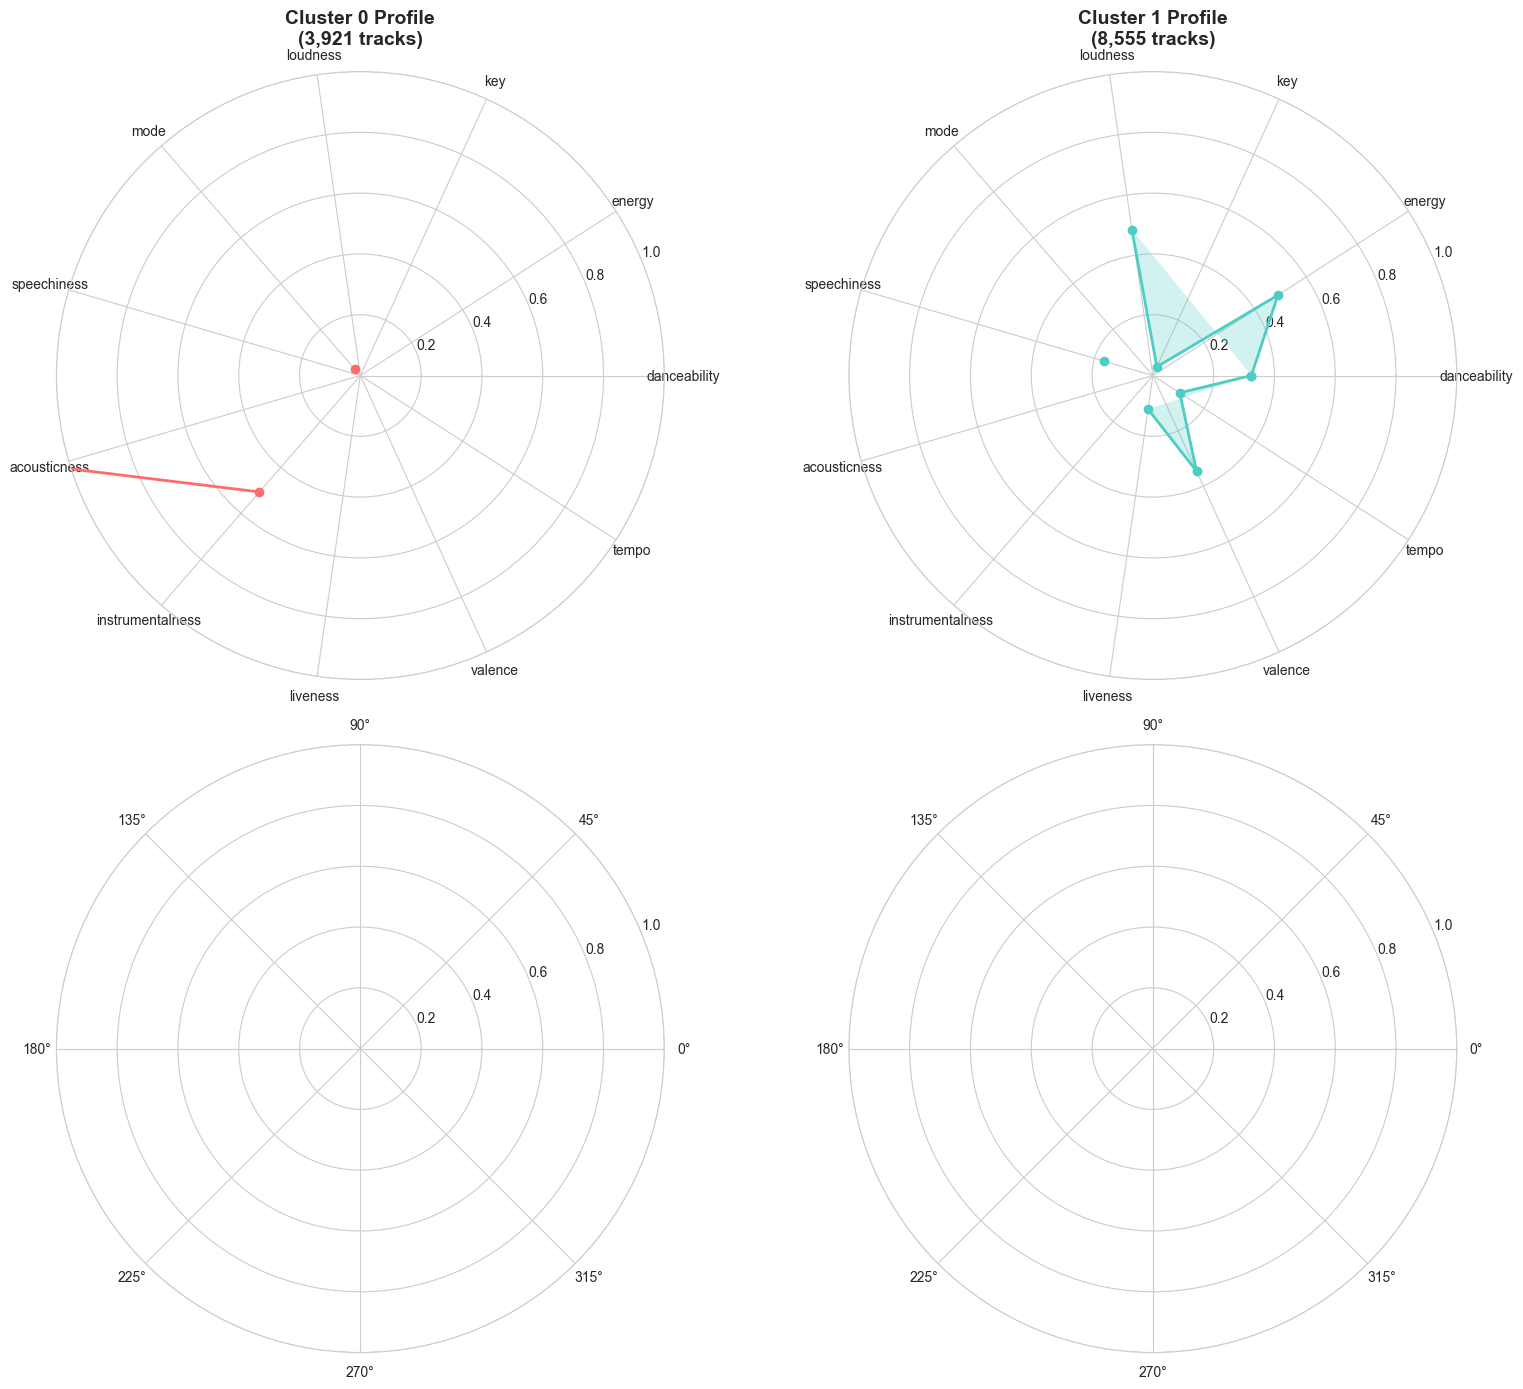

✅ Radar chart vẽ xong


In [6]:
# ===== VISUALIZATION: RADAR CHART CHO MỖI CLUSTER =====
print("\n" + "="*100)
print("📊 VISUALIZATION: RADAR CHART - ĐẶC TÍNH CỦA MỖI CLUSTER")
print("="*100)

from math import pi

# Chuẩn bị dữ liệu
cluster_means = []
for cluster_id in range(optimal_k):
    cluster_data = df[df['cluster'] == cluster_id][audio_features]
    # Normalize to 0-1 range for better visualization
    means = cluster_data.mean()
    cluster_means.append(means)

# Tạo radar chart
fig, axes = plt.subplots(2, 2, figsize=(16, 14), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

categories = audio_features
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for idx in range(optimal_k):
    ax = axes[idx]
    
    values = cluster_means[idx].tolist()
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, color=colors[idx], label=f'Cluster {idx}')
    ax.fill(angles, values, alpha=0.25, color=colors[idx])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=10)
    ax.set_ylim(0, 1)
    ax.set_title(f'Cluster {idx} Profile\n({len(df[df["cluster"] == idx]):,} tracks)', 
                 size=14, fontweight='bold', pad=20)
    ax.grid(True)

plt.tight_layout()
plt.savefig('../outputs/figures/cluster_radar_charts.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Radar chart vẽ xong")


📊 VISUALIZATION: PCA 2D - CLUSTERING RESULT
✅ PCA explained variance: 41.92%
   PC1: 30.04%
   PC2: 11.88%


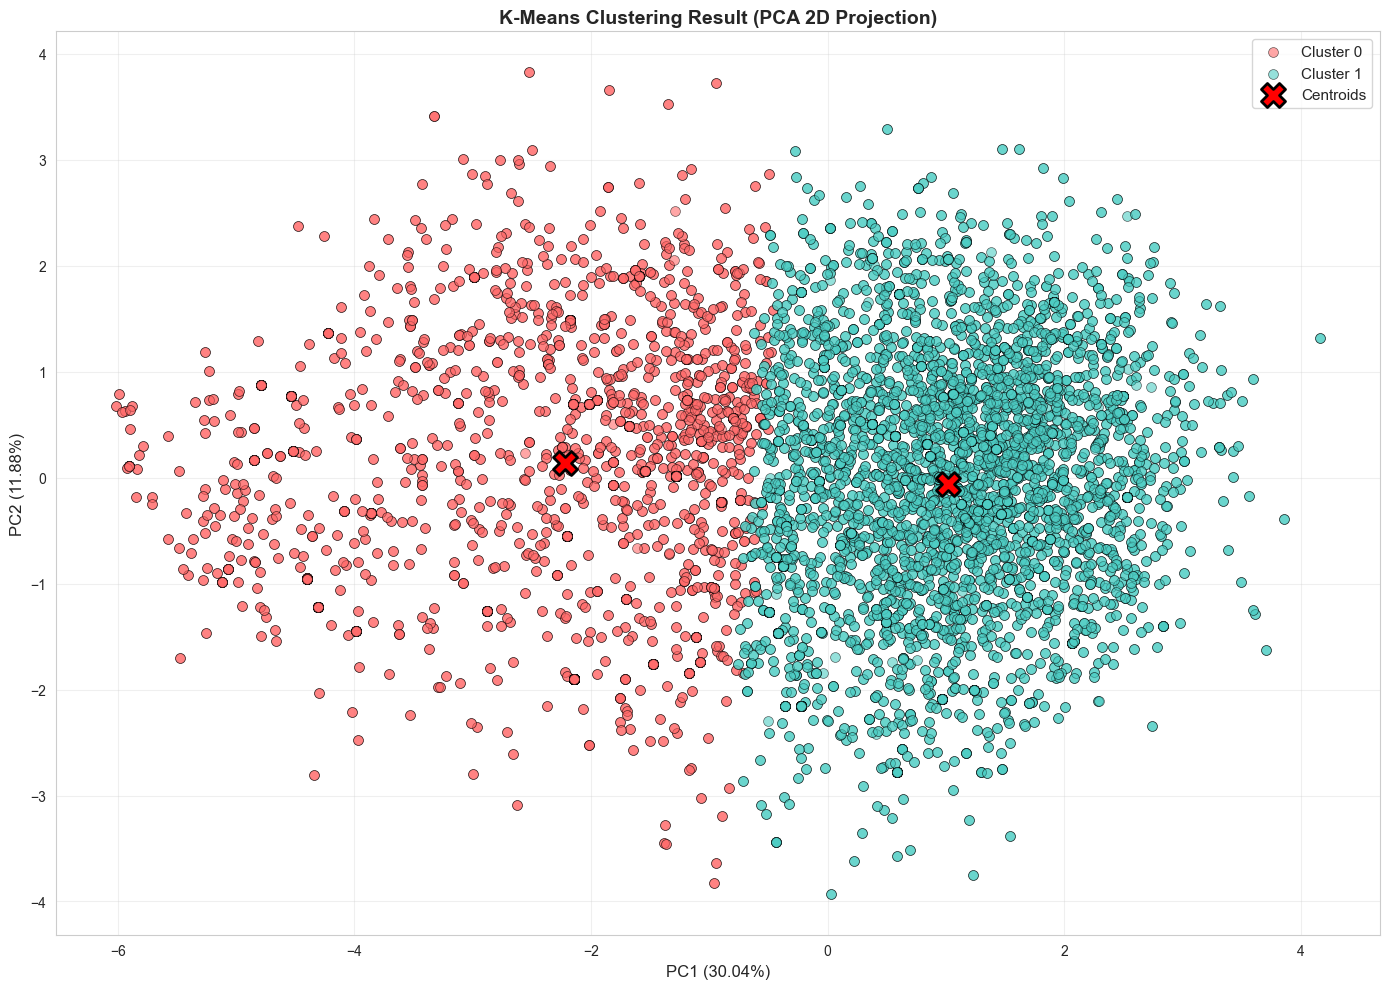

✅ PCA scatter plot vẽ xong


In [7]:
# ===== VISUALIZATION: PCA 2D SCATTER PLOT =====
print("\n" + "="*100)
print("📊 VISUALIZATION: PCA 2D - CLUSTERING RESULT")
print("="*100)

# Áp dụng PCA để giảm chiều
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

print(f"✅ PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")
print(f"   PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"   PC2: {pca.explained_variance_ratio_[1]:.2%}")

# Vẽ scatter plot
fig, ax = plt.subplots(figsize=(14, 10))

for cluster_id in range(optimal_k):
    mask = df['cluster'] == cluster_id
    ax.scatter(df_pca[mask, 0], df_pca[mask, 1], 
              c=colors[cluster_id], label=f'Cluster {cluster_id}',
              alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
          c='red', marker='X', s=300, edgecolors='black', linewidth=2,
          label='Centroids')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=12)
ax.set_title('K-Means Clustering Result (PCA 2D Projection)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/clustering_pca_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ PCA scatter plot vẽ xong")

In [8]:
# ===== INSIGHTS RÚT RA TỪ CLUSTERING =====
print("\n" + "="*100)
print("💡 INSIGHTS RÚT RA TỪ CLUSTERING")
print("="*100)

for cluster_id in range(optimal_k):
    cluster_data = df[df['cluster'] == cluster_id][audio_features]
    
    print(f"\n🎵 CLUSTER {cluster_id} - Đặc Điểm:")
    print("   " + "-"*80)
    
    # Tìm feature nổi bật nhất
    means = cluster_data.mean()
    
    # Top 3 cao nhất
    top_3_high = means.nlargest(3)
    print(f"   ⬆️  Features cao nhất:")
    for feat, val in top_3_high.items():
        print(f"       • {feat}: {val:.4f}")
    
    # Top 3 thấp nhất
    top_3_low = means.nsmallest(3)
    print(f"   ⬇️  Features thấp nhất:")
    for feat, val in top_3_low.items():
        print(f"       • {feat}: {val:.4f}")
    
    # Mô tả cluster
    if means['energy'] > 0.6 and means['danceability'] > 0.6:
        music_type = "🎉 Energetic & Danceable - EDM/Dance/Pop"
    elif means['acousticness'] > 0.6:
        music_type = "🎸 Acoustic - Indie/Folk/Singer-Songwriter"
    elif means['instrumentalness'] > 0.5:
        music_type = "🎹 Instrumental - Classical/Jazz/Ambient"
    elif means['loudness'] < -8:
        music_type = "🔇 Quiet & Calm - Lo-Fi/Ambient/Sleep Music"
    else:
        music_type = "🎵 Balanced - Pop/Alternative/General"
    
    print(f"   🎯 Music Genre: {music_type}")
    print(f"   📊 Sample Size: {len(cluster_data):,} tracks")


💡 INSIGHTS RÚT RA TỪ CLUSTERING

🎵 CLUSTER 0 - Đặc Điểm:
   --------------------------------------------------------------------------------
   ⬆️  Features cao nhất:
       • acousticness: 1.0621
       • instrumentalness: 0.5069
       • mode: 0.0266
   ⬇️  Features thấp nhất:
       • energy: -1.0668
       • loudness: -1.0587
       • valence: -0.7544
   🎯 Music Genre: 🎸 Acoustic - Indie/Folk/Singer-Songwriter
   📊 Sample Size: 3,921 tracks

🎵 CLUSTER 1 - Đặc Điểm:
   --------------------------------------------------------------------------------
   ⬆️  Features cao nhất:
       • energy: 0.4890
       • loudness: 0.4852
       • valence: 0.3458
   ⬇️  Features thấp nhất:
       • acousticness: -0.4868
       • instrumentalness: -0.2323
       • mode: -0.0122
   🎯 Music Genre: 🎵 Balanced - Pop/Alternative/General
   📊 Sample Size: 8,555 tracks


In [9]:
# ===== LƯU KẾT QUẢ CLUSTERING =====
print("\n" + "="*100)
print("💾 LƯU KẾT QUẢ CLUSTERING")
print("="*100)

# Lưu dataframe với cluster labels
output_file = '../data/processed/spotify_with_clusters.csv'
df.to_csv(output_file, index=False)

print(f"\n✅ Lưu thành công: {output_file}")
print(f"   Shape: {df.shape}")
print(f"   Columns: {len(df.columns)}")

# Lưu cluster profiles
cluster_profile_file = '../data/processed/cluster_profiles.csv'
df_profiles.to_csv(cluster_profile_file, index=False)

print(f"\n✅ Lưu cluster profiles: {cluster_profile_file}")
print(f"   Shape: {df_profiles.shape}")

print("\n" + "="*100)
print("🎉 CLUSTERING ANALYSIS HOÀN TẤT!")
print("="*100)


💾 LƯU KẾT QUẢ CLUSTERING

✅ Lưu thành công: ../data/processed/spotify_with_clusters.csv
   Shape: (12476, 327)
   Columns: 327

✅ Lưu cluster profiles: ../data/processed/cluster_profiles.csv
   Shape: (2, 13)

🎉 CLUSTERING ANALYSIS HOÀN TẤT!
